# 02 — Feature Set Comparison: History vs. Slope/DEM

Tests, on the synthetic dataset from notebook 01, whether **Feature Set A**
(soil + rainfall + historical landslide data) or **Feature Set B**
(soil + rainfall + slope/DEM) is more predictive of `landslide_occurred`, using the
same two models (XGBoost, LightGBM) on both.

**Why this is a fair test, not a foregone conclusion:** the synthetic label
(`labeling.py`) was generated from slope + soil + rainfall + a **latent** factor `L`
that neither feature set observes directly. Feature Set B sees slope/soil/rainfall
cleanly but is blind to `L`. Feature Set A sees soil/rainfall cleanly but only recovers
a noisy, indirect view of `L` through the historical failure count. The weights that
define this latent process were fixed in `config.py` *before* any model was trained here
and are not retuned based on the results below.

In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install xgboost
%pip install lightgbm
import sys
import pathlib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from scipy import stats
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from landslide_toy import config, labeling, viz

viz.set_style()
df = pd.read_csv(ROOT / "data" / "synthetic" / "nuwara_eliya_synthetic_sites.csv")
print(df.shape)
df.head()


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


(450, 17)


,site_id,division,soil_type,soil_weight,rainfall_annual_mm,max_24h_rainfall_mm,rainfall_alert_level,slope_deg,slope_band,historical_failure_count_20yr,historical_failure_density_per_km2,days_since_last_failure,slope_risk,latent_l,true_hazard_z,hazard_probability,landslide_occurred
0,KOT-0107,Kotmale,Mountain Regosol,0.60,2092.721300,23.513159,No Alert,24.042648,Moderate,3,3.0,1141.808710,0.468088,0.626958,0.413915,0.098104,0
1,KOT-0144,Kotmale,Red-Yellow Podzolic,0.75,2816.868078,24.572346,No Alert,37.927049,Very High,6,6.0,1644.268810,0.930902,0.811937,0.646346,0.526436,0
2,WAL-0117,Walapane,Reddish-Brown Latosolic,0.35,2303.814745,36.916168,No Alert,20.903323,Moderate,1,1.0,80.421672,0.363444,0.577055,0.281584,0.028146,0
3,WAL-0030,Walapane,Reddish-Brown Latosolic,0.35,1964.408502,46.823615,No Alert,17.706893,Moderate,1,1.0,4394.577834,0.256896,0.331874,0.190872,0.011556,0
4,KOT-0115,Kotmale,Mountain Regosol,0.60,2246.736874,111.649643,Alert,29.607091,High,1,1.0,6122.051084,0.653570,0.324047,0.445700,0.130038,0


## 1. Build Feature Set A and Feature Set B

In [2]:
def encode(frame, categorical_cols, numeric_cols):
    dummies = pd.get_dummies(frame[categorical_cols].astype(str), prefix=categorical_cols)
    numeric = frame[numeric_cols].reset_index(drop=True)
    return pd.concat([numeric, dummies.reset_index(drop=True)], axis=1)


FEATURE_SET_A_CATEGORICAL = ["soil_type", "rainfall_alert_level"]
FEATURE_SET_A_NUMERIC = [
    "soil_weight", "rainfall_annual_mm", "max_24h_rainfall_mm",
    "historical_failure_count_20yr", "historical_failure_density_per_km2",
    "days_since_last_failure",
]

FEATURE_SET_B_CATEGORICAL = ["soil_type", "rainfall_alert_level", "slope_band"]
FEATURE_SET_B_NUMERIC = [
    "soil_weight", "rainfall_annual_mm", "max_24h_rainfall_mm", "slope_deg", "slope_risk",
]

X_A = encode(df, FEATURE_SET_A_CATEGORICAL, FEATURE_SET_A_NUMERIC)
X_B = encode(df, FEATURE_SET_B_CATEGORICAL, FEATURE_SET_B_NUMERIC)
y = df["landslide_occurred"].to_numpy()

print("Feature Set A columns:", list(X_A.columns))
print("Feature Set B columns:", list(X_B.columns))


Feature Set A columns: ['soil_weight', 'rainfall_annual_mm', 'max_24h_rainfall_mm', 'historical_failure_count_20yr', 'historical_failure_density_per_km2', 'days_since_last_failure', 'soil_type_Mountain Regosol', 'soil_type_Red-Yellow Podzolic', 'soil_type_Reddish-Brown Latosolic', 'rainfall_alert_level_Alert', 'rainfall_alert_level_Evacuation', 'rainfall_alert_level_No Alert', 'rainfall_alert_level_Watch']
Feature Set B columns: ['soil_weight', 'rainfall_annual_mm', 'max_24h_rainfall_mm', 'slope_deg', 'slope_risk', 'soil_type_Mountain Regosol', 'soil_type_Red-Yellow Podzolic', 'soil_type_Reddish-Brown Latosolic', 'rainfall_alert_level_Alert', 'rainfall_alert_level_Evacuation', 'rainfall_alert_level_No Alert', 'rainfall_alert_level_Watch', 'slope_band_High', 'slope_band_Low', 'slope_band_Moderate', 'slope_band_Very High', 'slope_band_Very Low']


## 2. Paired repeated stratified cross-validation

In [3]:
MODEL_FACTORY = {
    "XGBoost": lambda: XGBClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=config.SEED, verbosity=0,
    ),
    "LightGBM": lambda: LGBMClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=10,
        random_state=config.SEED, verbosity=-1,
    ),
}
FEATURE_SETS = {"Set A (soil+rainfall+history)": X_A, "Set B (soil+rainfall+slope)": X_B}

strat_key = df["division"].astype(str) + "_" + df["landslide_occurred"].astype(str)
splitter = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=config.SEED)
placeholder_X = np.zeros((len(df), 1))

records = []
for split_id, (train_idx, test_idx) in enumerate(splitter.split(placeholder_X, strat_key)):
    y_train, y_test = y[train_idx], y[test_idx]
    for model_name, factory in MODEL_FACTORY.items():
        for set_name, X_full in FEATURE_SETS.items():
            X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
            model = factory()
            model.fit(X_train, y_train)
            proba = model.predict_proba(X_test)[:, 1]
            pred = (proba >= 0.5).astype(int)
            records.append({
                "split_id": split_id, "model": model_name, "feature_set": set_name,
                "accuracy": accuracy_score(y_test, pred),
                "precision": precision_score(y_test, pred, zero_division=0),
                "recall": recall_score(y_test, pred, zero_division=0),
                "f1": f1_score(y_test, pred, zero_division=0),
                "roc_auc": roc_auc_score(y_test, proba),
                "pr_auc": average_precision_score(y_test, proba),
            })

results = pd.DataFrame(records)
results.head()


,split_id,model,feature_set,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0,XGBoost,Set A (soil+rainfall+history),0.788889,0.444444,0.222222,0.296296,0.674383,0.328956
1,0,XGBoost,Set B (soil+rainfall+slope),0.755556,0.166667,0.055556,0.083333,0.701389,0.334710
2,0,LightGBM,Set A (soil+rainfall+history),0.766667,0.363636,0.222222,0.275862,0.692130,0.337940
3,0,LightGBM,Set B (soil+rainfall+slope),0.755556,0.000000,0.000000,0.000000,0.712191,0.351912
4,1,XGBoost,Set A (soil+rainfall+history),0.755556,0.333333,0.222222,0.266667,0.633488,0.280391


## 3. Comparison table & charts

In [4]:
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
summary = results.groupby(["model", "feature_set"])[metric_cols].agg(["mean", "std"])
summary.round(3)


accuracy        precision         \
                                           mean    std      mean    std   
model    feature_set                                                      
LightGBM Set A (soil+rainfall+history)    0.769  0.029     0.411  0.112   
         Set B (soil+rainfall+slope)      0.778  0.028     0.406  0.186   
XGBoost  Set A (soil+rainfall+history)    0.771  0.034     0.408  0.173   
         Set B (soil+rainfall+slope)      0.779  0.033     0.435  0.170   

                                       recall            f1        roc_auc  \
                                         mean    std   mean    std    mean   
model    feature_set                                                         
LightGBM Set A (soil+rainfall+history)  0.237  0.075  0.295  0.077   0.703   
         Set B (soil+rainfall+slope)    0.228  0.114  0.287  0.135   0.711   
XGBoost  Set A (soil+rainfall+history)  0.204  0.086  0.267  0.105   0.720   
         Set B (soil+rainfall+slope)    0.244  0.114  0.305  0.130   0.704   

                                              pr_auc         
                                          std   mean    std  
model    feature_set                                         
LightGBM Set A (soil+rainfall+history)  0.076  0.400  0.086  
         Set B (soil+rainfall+slope)    0.070  0.430  0.098  
XGBoost  Set A (soil+rainfall+history)  0.077  0.402  0.094  
         Set B (soil+rainfall+slope)    0.082  0.412  0.104

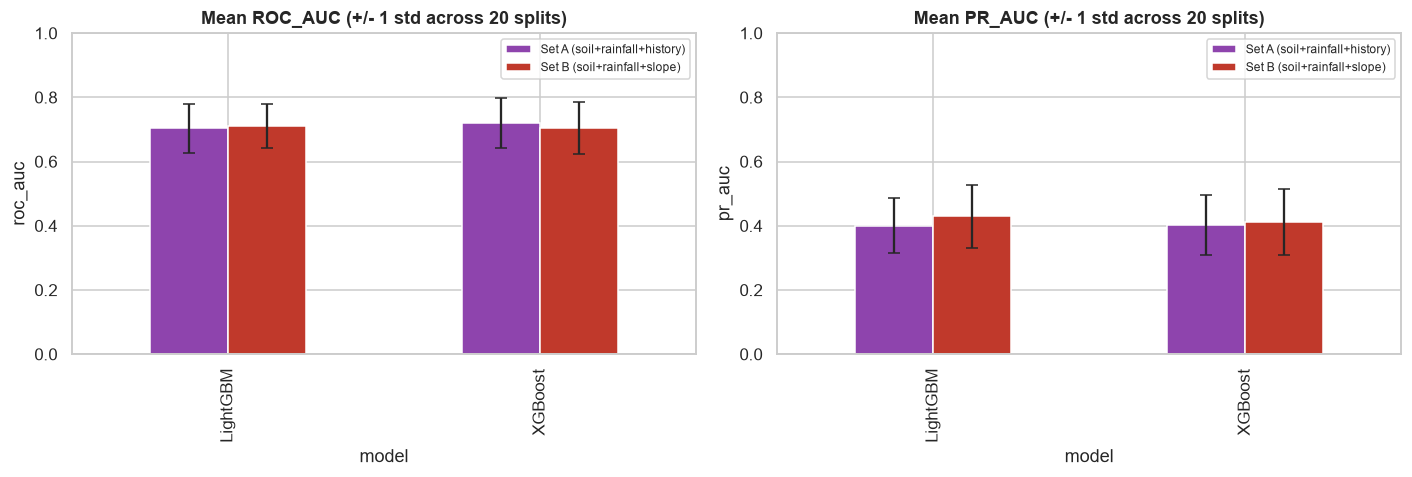

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for metric, ax in zip(["roc_auc", "pr_auc"], axes):
    pivot_mean = results.groupby(["model", "feature_set"])[metric].mean().unstack()
    pivot_std = results.groupby(["model", "feature_set"])[metric].std().unstack()
    pivot_mean.plot(kind="bar", yerr=pivot_std, ax=ax, capsize=4,
                     color=[viz.FEATURE_SET_COLORS[c] for c in pivot_mean.columns])
    ax.set_title(f"Mean {metric.upper()} (+/- 1 std across {results['split_id'].nunique()} splits)")
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 4. Paired comparison (honest significance check)

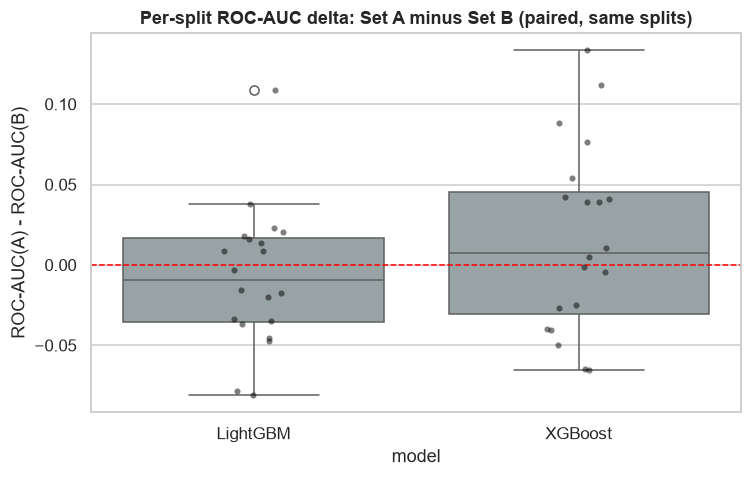

LightGBM: mean delta(A-B) = -0.0079, Wilcoxon p = 0.3300 (B > A)
XGBoost: mean delta(A-B) = +0.0161, Wilcoxon p = 0.3118 (A > B)


In [6]:
paired = results.pivot_table(index=["split_id", "model"], columns="feature_set", values="roc_auc").reset_index()
paired["delta_A_minus_B"] = paired["Set A (soil+rainfall+history)"] - paired["Set B (soil+rainfall+slope)"]

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=paired, x="model", y="delta_A_minus_B", ax=ax, color="#95A5A6")
sns.stripplot(data=paired, x="model", y="delta_A_minus_B", ax=ax, color="black", alpha=0.5, size=4)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Per-split ROC-AUC delta: Set A minus Set B (paired, same splits)")
ax.set_ylabel("ROC-AUC(A) - ROC-AUC(B)")
plt.tight_layout()
plt.show()

for model_name, group in paired.groupby("model"):
    stat, pvalue = stats.wilcoxon(group["delta_A_minus_B"])
    direction = "A > B" if group["delta_A_minus_B"].mean() > 0 else "B > A"
    print(f"{model_name}: mean delta(A-B) = {group['delta_A_minus_B'].mean():+.4f}, "
          f"Wilcoxon p = {pvalue:.4f} ({direction})")


## 5. Illustrative single-split ROC / PR curves and confusion matrices

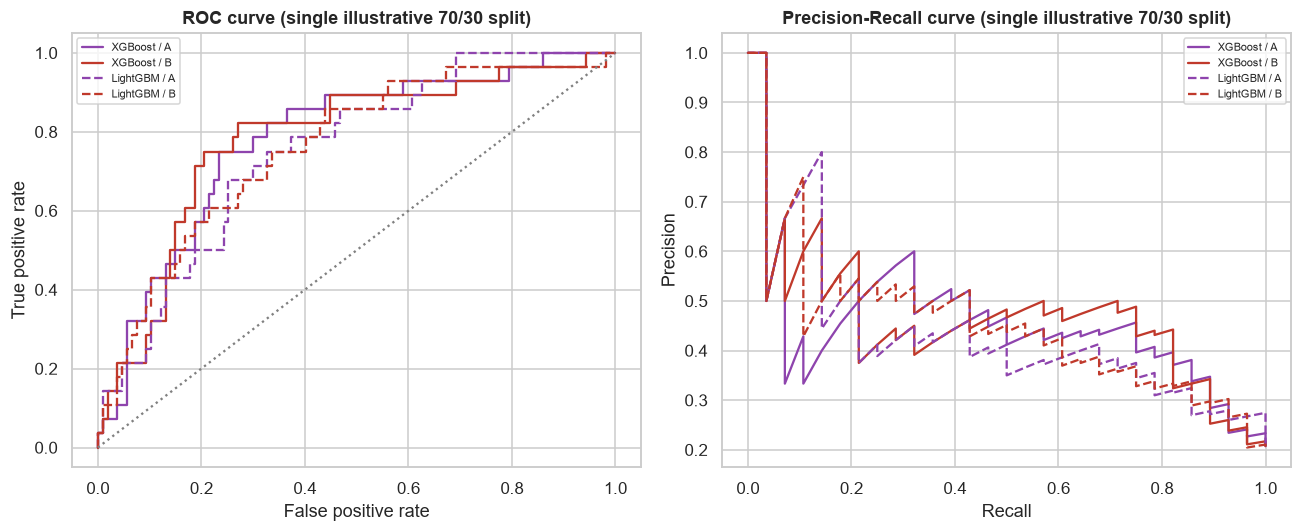

In [7]:
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.3, random_state=config.SEED, stratify=strat_key
)
y_train, y_test = y[train_idx], y[test_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fitted = {}
for model_name, factory in MODEL_FACTORY.items():
    for set_name, X_full in FEATURE_SETS.items():
        model = factory()
        model.fit(X_full.iloc[train_idx], y_train)
        proba = model.predict_proba(X_full.iloc[test_idx])[:, 1]
        fitted[(model_name, set_name)] = (model, proba)

        fpr, tpr, _ = roc_curve(y_test, proba)
        axes[0].plot(fpr, tpr, label=f"{model_name} / {set_name.split(' ')[1]}",
                     color=viz.FEATURE_SET_COLORS[set_name],
                     linestyle="-" if model_name == "XGBoost" else "--")

        prec, rec, _ = precision_recall_curve(y_test, proba)
        axes[1].plot(rec, prec, label=f"{model_name} / {set_name.split(' ')[1]}",
                     color=viz.FEATURE_SET_COLORS[set_name],
                     linestyle="-" if model_name == "XGBoost" else "--")

axes[0].plot([0, 1], [0, 1], color="gray", linestyle=":")
axes[0].set_title("ROC curve (single illustrative 70/30 split)")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(fontsize=7)

axes[1].set_title("Precision-Recall curve (single illustrative 70/30 split)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()


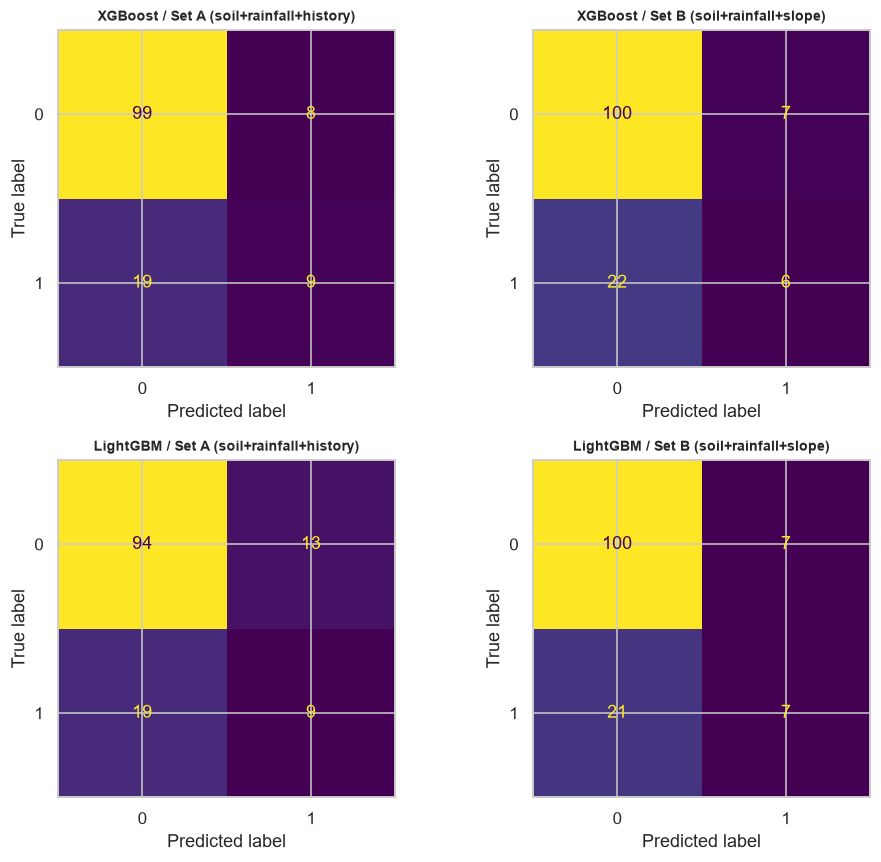

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, ((model_name, set_name), (model, proba)) in zip(axes.ravel(), fitted.items()):
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(f"{model_name} / {set_name}", fontsize=9)
plt.tight_layout()
plt.show()


## 6. Sensitivity check: varying the latent factor's weight

The comparison above depends on how much of the "true" hazard is driven by the latent
factor `L` that Feature Set A can only see indirectly (through history) and Feature Set
B cannot see at all. Rather than presenting the baseline weight (`config.HAZARD_WEIGHT_LATENT
= 0.20`) as the only possible truth, this section re-labels the *same* synthetic sites
under a few different assumed weights and re-runs a lighter single-split comparison for
one model, to show **under which assumptions each feature set wins**.

In [9]:
def relabel_with_latent_weight(frame, weight_latent, seed=config.SEED):
    rng = config.make_rng(seed + 100)
    rterm = labeling.rainfall_term(frame["max_24h_rainfall_mm"])
    noise = rng.normal(0, config.HAZARD_NOISE_SD, size=len(frame))
    z = (
        config.HAZARD_WEIGHT_SLOPE * frame["slope_risk"].to_numpy()
        + config.HAZARD_WEIGHT_SOIL * frame["soil_weight"].to_numpy()
        + config.HAZARD_WEIGHT_RAINFALL * rterm
        + weight_latent * frame["latent_l"].to_numpy()
        + noise
    )
    threshold = labeling.calibrate_threshold(z, config.HAZARD_SIGMOID_STEEPNESS, config.TARGET_PREVALENCE)
    prob = 1.0 / (1.0 + np.exp(-config.HAZARD_SIGMOID_STEEPNESS * (z - threshold)))
    return rng.binomial(1, prob)


sensitivity_rows = []
for weight_latent in [0.10, 0.20, 0.30]:
    y_sens = relabel_with_latent_weight(df, weight_latent)
    tr_idx, te_idx = train_test_split(
        np.arange(len(df)), test_size=0.3, random_state=config.SEED, stratify=y_sens
    )
    for set_name, X_full in FEATURE_SETS.items():
        model = MODEL_FACTORY["XGBoost"]()
        model.fit(X_full.iloc[tr_idx], y_sens[tr_idx])
        proba = model.predict_proba(X_full.iloc[te_idx])[:, 1]
        sensitivity_rows.append({
            "weight_latent": weight_latent, "feature_set": set_name,
            "roc_auc": roc_auc_score(y_sens[te_idx], proba),
        })

sens_df = pd.DataFrame(sensitivity_rows)
sens_pivot = sens_df.pivot(index="weight_latent", columns="feature_set", values="roc_auc")
sens_pivot["delta_A_minus_B"] = (
    sens_pivot["Set A (soil+rainfall+history)"] - sens_pivot["Set B (soil+rainfall+slope)"]
)
sens_pivot


feature_set,Set A (soil+rainfall+history),Set B (soil+rainfall+slope),delta_A_minus_B
weight_latent,,,
0.1,0.670000,0.699143,-0.029143
0.2,0.674141,0.687828,-0.013687
0.3,0.689284,0.715492,-0.026209


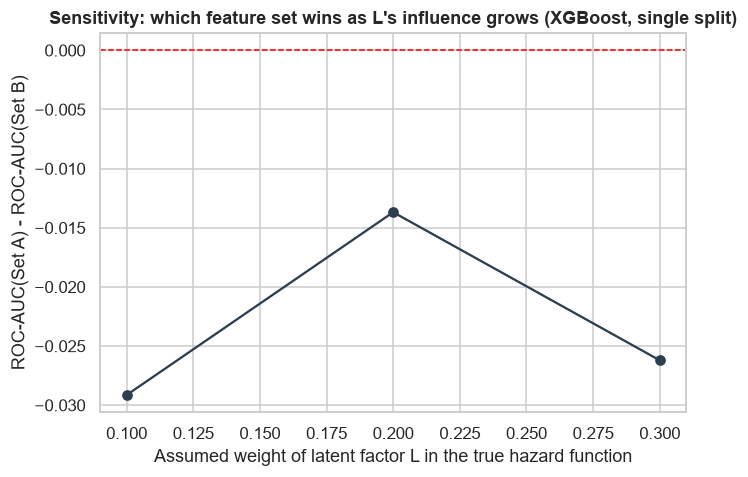

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(sens_pivot.index, sens_pivot["delta_A_minus_B"], marker="o", color="#2C3E50")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Assumed weight of latent factor L in the true hazard function")
ax.set_ylabel("ROC-AUC(Set A) - ROC-AUC(Set B)")
ax.set_title("Sensitivity: which feature set wins as L's influence grows (XGBoost, single split)")
plt.tight_layout()
plt.show()


## 7. Save the winning model for notebooks 03-04

In [12]:
baseline_mean = results.groupby(["model", "feature_set"])["roc_auc"].mean()
best_model_name, best_feature_set = baseline_mean.idxmax()
print(f"Best combination by mean ROC-AUC across {results['split_id'].nunique()} paired splits: "
      f"{best_model_name} on {best_feature_set} (mean ROC-AUC = {baseline_mean.max():.3f})")

X_best_full = FEATURE_SETS[best_feature_set]
final_model = MODEL_FACTORY[best_model_name]()
final_model.fit(X_best_full.iloc[train_idx], y_train)
final_proba = final_model.predict_proba(X_best_full.iloc[test_idx])[:, 1]
print(f"Held-out 70/30 split ROC-AUC: {roc_auc_score(y_test, final_proba):.3f}")

models_dir = ROOT / "outputs" / "models"
models_dir.mkdir(parents=True, exist_ok=True)
bundle = {
    "model": final_model,
    "model_name": best_model_name,
    "feature_set_name": best_feature_set,
    "feature_columns": list(X_best_full.columns),
    "categorical_cols": FEATURE_SET_A_CATEGORICAL if "history" in best_feature_set else FEATURE_SET_B_CATEGORICAL,
    "numeric_cols": FEATURE_SET_A_NUMERIC if "history" in best_feature_set else FEATURE_SET_B_NUMERIC,
    "test_index": test_idx.tolist(),
    "train_index": train_idx.tolist(),
}
joblib.dump(bundle, models_dir / "best_model.joblib")
print(f"Saved model bundle to {models_dir / 'best_model.joblib'}")


Best combination by mean ROC-AUC across 20 paired splits: XGBoost on Set A (soil+rainfall+history) (mean ROC-AUC = 0.720)
Held-out 70/30 split ROC-AUC: 0.856
Saved model bundle to c:\Users\Sadumina Rathnayaka\Desktop\Reserach Dummy\outputs\models\best_model.joblib


## 8. Interpretation & caveats

- This result reflects the researcher's own synthetic causal assumptions
  (`config.HAZARD_WEIGHT_*`), fixed before training — **it is a methodology
  demonstration, not a real-world finding** about Nuwara Eliya landslide risk.
- The sensitivity plot above shows the comparison is not fixed in stone: it depends on
  how much unobserved local variation actually drives real landslides, which is
  precisely the open empirical question real NBRO historical records would answer.
- When real data is available, only `01_data_generation_and_eda.ipynb`'s data-generation
  cells need to be replaced with real data loaders — this notebook's feature-set
  definitions, CV methodology, and paired-significance test can run unchanged.

**Next:** `03_severity_index.ipynb` turns the saved model's probability output into a
0-10 Landslide Severity Index.